# Photobleaching heatmap
Creates a 2D heatmap showing frequency of photobleaching steps in single kymograph trace.  Input photobleaching step files are generated with [photobleaching-and-stepfinding scripts](../photobleaching-and-stepfinding/).

In [1]:
# Importing libraries
from kymotools.utils import fileutils

import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [2]:
# Parameters
input_path = './examples/input/' # Path to folder containing CSVs to process
output_path = './examples/output/' # Path to folder in which to save ouput
heatmap_size = 4 # Maximum number of steps to show

In [3]:
def process(input_path, output_path, name):
    # File loading
    with open(input_path+name, newline='') as f:
        reader = csv.reader(f)
        data = list(reader)
        
    # Creating heatmap image
    arr = np.asarray(data)
    heatmap = np.zeros((heatmap_size,heatmap_size))

    for row in arr:
        r = min(row[0].astype(np.uint8),heatmap_size-1)
        c = min(row[1].astype(np.uint8),heatmap_size-1)

        heatmap[r,c] = heatmap[r,c] + 1
        
    # Adding axes and saving
    fig = plt.figure()
    im_plt = plt.imshow(heatmap)
    ax = plt.gca()
    ax.invert_yaxis()
    ax.set_xticks(range(heatmap_size))
    ax.set_yticks(range(heatmap_size))
    plt.set_cmap('cividis')
    cbar = ax.figure.colorbar(im_plt, ax=ax)

    # Adding count text to each element
    for i in range(heatmap_size):
        for j in range(heatmap_size):
            text = ax.text(j, i, heatmap[i, j].astype(np.uint16), ha="center", va="center", color="w")

    # Saving plot
    rootname = os.path.splitext(name)[0]
    plt.savefig(output_path+rootname+"_heatmap.svg")
    plt.savefig(output_path+rootname+"_heatmap.png")

Processing:  Photobleaching steps_red and green channels.csv


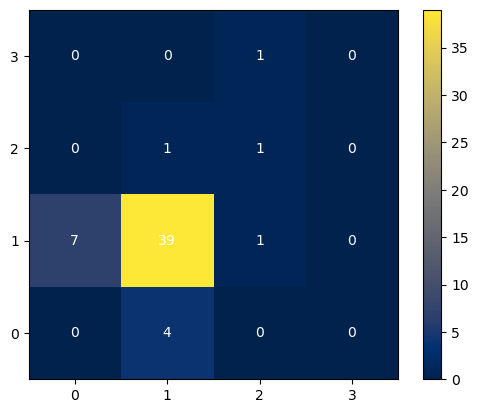

In [4]:
# Looping over all files in folder, processing any tifs
for name in os.listdir(input_path):
    print("Processing: ",name)
    if os.path.splitext(name)[1] == ".csv":
        process(input_path, output_path, name)